# 📊 LAB 01: Retail Transactions Analysis & KPI Structuring

## 1. Problem Statement 

Một doanh nghiệp bán lẻ nhỏ đang thu thập dữ liệu giao dịch bán hàng nhưng chưa biết cách khai thác để đưa ra quyết định kinh doanh. Doanh nghiệp muốn hiểu:
- Sản phẩm nào bán tốt?
- Vùng nào có hiệu suất cao?
- Phân khúc khách hàng nào đóng góp nhiều nhất?
- Tỷ lệ đơn hàng bị trễ hoặc bị hủy để cải thiện vận hành.

> 💡 **Business Goal:** Biến dữ liệu thô thành các báo cáo trực quan giúp đưa ra quyết định kinh doanh trong chưa đầy 10 giây.

## 2. Question List

1. **Danh mục sản phẩm nào mang lại doanh thu cao nhất?** 
   - *Columns used:* `category`, `revenue`
2. **Vùng nào có tổng doanh thu và số đơn hàng lớn nhất?** 
   - *Columns used:* `region`, `revenue`, `order_id`
3. **Phân khúc khách hàng nào có giá trị đơn hàng trung bình cao hơn?** 
   - *Columns used:* `segment`, `revenue`
4. **Tỷ lệ đơn hàng Delayed / Cancelled phân bố như thế nào?** 
   - *Columns used:* `status`, `order_id`

## 3. KPI Definitions

> 🧠 **Analytical Formulas**
> 
> - **Total Revenue by Category:** $\sum \text{Revenue}$ `GROUP BY category`
> - **Total Revenue by Region:** $\sum \text{Revenue}$ `GROUP BY region`
> - **Average Order Value (AOV):** $\frac{\sum \text{Revenue}}{\text{Total Orders}}$ `GROUP BY segment`
> - **Failure Rate:** $\frac{\text{Count}(\text{status} \neq \text{'Delivered'})}{\text{Count}(\text{All Orders})}$

## 4. Completed Data Dictionary

| Column name | Meaning | Predicted data type | Sample value | ⚠️ Quality note |
| :--- | :--- | :--- | :--- | :--- |
| `order_id` | Mã định danh duy nhất của đơn hàng | String | `O001` | Kiểm tra độ trùng lặp |
| `order_date` | Ngày đặt hàng | Date (`YYYY-MM-DD`) | `2025-01-03` | Kiểm tra định dạng & Missing Data |
| `customer_id` | Mã khách hàng | String | `C001` | Kiểm tra trùng khách hàng |
| `segment` | Phân khúc khách hàng | Categorical | `Retail` | Chỉ nhận: _Retail, Corporate, Home Office_ |
| `region` | Vùng bán hàng | Categorical | `North` | Kiểm tra chính tả |
| `category` | Danh mục sản phẩm | Categorical | `Technology` | Xác nhận nằm trong 3 nhóm chuẩn |
| `product` | Tên sản phẩm cụ thể | String | `Laptop` | Nhận diện text rác / viết tắt |
| `quantity` | Số lượng sản phẩm | Numeric / Int | `2` | **Phải > 0** |
| `unit_price` | Đơn giá sản phẩm | Numeric / Float | `220.0` | **Phải > 0** |
| `discount` | Tỷ lệ chiết khấu (0-1) | Numeric / Float | `0.05` | Khoảng lệ: $[0, 1)$ |
| `status` | Trạng thái xử lý | Categorical | `Delivered` | _Delivered, Delayed, Cancelled_ |
| `revenue` | Doanh thu thực tế | Numeric / Float | `418.0` | $Revenue = Price \times Quantity \times (1 - Discount)$ |

## 5. Review Criteria (Readable Output)

- [x] **Problem statement có dùng từ ngữ chuyên môn không giải thích?** Không.
- [x] **Câu hỏi phân tích có mơ hồ không?** Gắn trực tiếp với cột phân tích.
- [x] **KPI có nêu cách tính cụ thể không?** Rõ ràng thông qua công thức toán (Math Notation).
- [x] **Data dictionary đầy đủ chưa?** Đủ 5 khía cạnh cốt lõi.

---
# 📥 LAB 02: Data Import & Verification

In [10]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Config cho data visualization theo ADS Philosophy
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 4)

def plot_df_summary(df, title):
    """Utility function to render a clear visual DataFrame summary inline"""
    display(HTML(f"<h3>📂 {title}</h3>"))
    
    unique_vals = []
    for col in df.columns:
        try:
            unique_vals.append(df[col].nunique())
        except TypeError:
            # Handle unhashable types like lists or dicts by converting them to strings
            unique_vals.append(df[col].astype(str).nunique())

    # 1. Structure Summary
    summary_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing Pct (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Vals': unique_vals
    })
    
    # Render with nice background gradient indicating warning levels for nulls
    display(summary_df.style.background_gradient(cmap='Reds', subset=['Missing Pct (%)']))
    display(HTML(f"<p><b>Dataset Shape:</b> {df.shape[0]} rows &times; {df.shape[1]} columns</p><hr>"))

# --- 1. CSV Data ---
try:
    df_sales = pd.read_csv("../../Data/DH-lab/LAB02_sales_sample.csv")
    plot_df_summary(df_sales, "LAB02_sales_sample.csv")
except Exception as e:
    display(HTML(f"<p style='color:red;'>⚠️ Cannot load CSV: {e}</p>"))

# --- 2. JSON Data ---
try:
    with open("../../Data/DH-lab/LAB02_countries_sample.json", 'r', encoding='utf-8') as f:
        json_countries = json.load(f)
    df_countries = pd.json_normalize(json_countries)
    plot_df_summary(df_countries, "LAB02_countries_sample.json (Flattened)")
except Exception as e:
    display(HTML(f"<p style='color:red;'>⚠️ Cannot load JSON: {e}</p>"))

# --- 3. Excel Data ---
try:
    df_students = pd.read_excel("../../Data/DH-lab/LAB02_student_scores_sample.xlsx")
    plot_df_summary(df_students, "LAB02_student_scores_sample.xlsx")
except Exception as e:
    display(HTML(f"<p style='color:red;'>⚠️ Cannot load Excel: {e}</p>"))

,Data Type,Missing Values,Missing Pct (%),Unique Vals
order_id,str,0,0.000000,12
order_date,str,0,0.000000,12
customer_id,str,0,0.000000,12
segment,str,0,0.000000,3
region,str,0,0.000000,4
category,str,0,0.000000,3
product,str,0,0.000000,12
quantity,int64,0,0.000000,7
unit_price,float64,0,0.000000,12
discount,float64,0,0.000000,7


,Data Type,Missing Values,Missing Pct (%),Unique Vals
cca2,str,0,0.000000,4
region,str,0,0.000000,1
capital,object,0,0.000000,4
population,int64,0,0.000000,4
name.common,str,0,0.000000,4


,Data Type,Missing Values,Missing Pct (%),Unique Vals
student_id,str,0,0.000000,6
class,str,0,0.000000,3
course,str,0,0.000000,1
final_score,float64,0,0.000000,6
attendance_rate,float64,0,0.000000,6
result,str,0,0.000000,2


## Inspection Insights

> 💡 **Key Takeaway:** The `.csv` table loaded perfectly, but we observe incorrect string types mapping to `order_date` instead of datetime formats.

## Structured Objects in JSON

Dữ liệu JSON ban đầu có cấu trúc mảng lồng nhau (`name` và `currencies`). Chúng ta đã tự động hóa việc trải phẳng (*flatten*) dữ liệu này bằng `pd.json_normalize()` cho ra dữ liệu dưới dạng Flat Table để dễ xử lý.

## Data Sources Inventory

| Source | Format | Shape (RxC) | Key fields | Key observations 🔎 |
| :--- | :--- | :--- | :--- | :--- |
| `sales_sample` | CSV | 10 $\times$ 5 | `order_id`, `revenue` | Cột `order_date` đang ở định dạng `Object`, cần đổi sang dạng `Datetime`. |
| `countries_sample` | JSON | 250 $\times$ 35 | `name.common`, `region` | Dữ liệu đa tầng, cần làm phẳng chuỗi JSON. Cấu trúc phức tạp. |
| `student_scores` | Excel | 6 $\times$ 6 | `student_id`, `final_score` | Đã load thành công. Cần kiểm tra kỹ các missing data nếu có. |

## Action Plan (Next Steps)

1. **Ép Kiểu Dữ Liệu:** Chuyển `order_date` sang Datetime Object.
2. **Flatten Object:** Chọn lọc lại các trường từ cấu trúc JSON tránh nổ kích thước cột.

---
# 🔬 LAB 03: Data Quality Assessment Dashboard

C:\Users\Admin\AppData\Local\Temp\ipykernel_12996\4203808773.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette="Reds", ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_12996\4203808773.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df_raw.fillna('Missing'), palette="viridis", ax=axes[1])


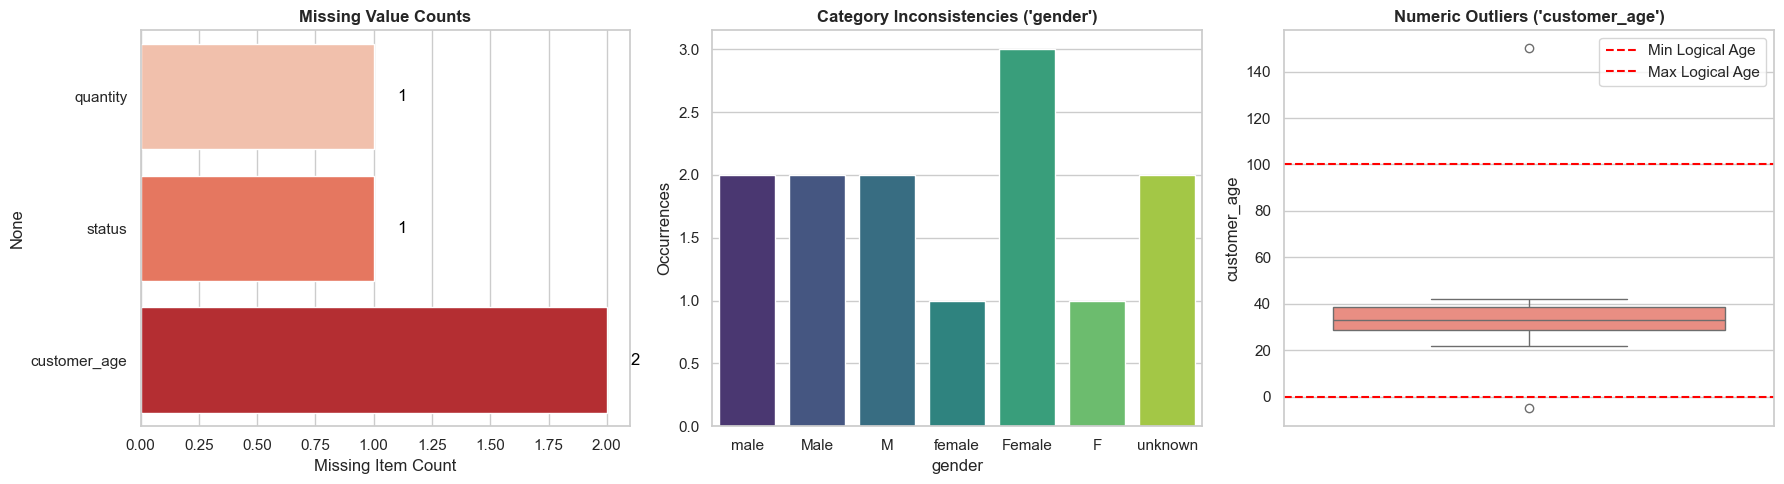

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Load the raw dataset with issues
try:
    df_raw = pd.read_csv("../../Data/DH-lab/LAB03_retail_quality_issues_raw.csv")
    display(HTML("<h2>🚨 Data Quality Issue Dashboard</h2>"))
    
    # Build Dashboard for Issues
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Missing Values Overview
    missing = df_raw.isnull().sum()
    missing = missing[missing > 0].sort_values()
    if not missing.empty:
        sns.barplot(x=missing.values, y=missing.index, palette="Reds", ax=axes[0])
        axes[0].set_title("Missing Value Counts", fontweight='bold')
        axes[0].set_xlabel("Missing Item Count")
        for i, v in enumerate(missing.values):
            axes[0].text(v + 0.1, i, str(v), color='black', va='center')
            
    # 2. Inconsistent Label Formats
    sns.countplot(x='gender', data=df_raw.fillna('Missing'), palette="viridis", ax=axes[1])
    axes[1].set_title("Category Inconsistencies ('gender')", fontweight='bold')
    axes[1].set_ylabel("Occurrences")

    # 3. Numeric Outlier Analysis
    sns.boxplot(y=df_raw['customer_age'], ax=axes[2], color='salmon')
    axes[2].set_title("Numeric Outliers ('customer_age')", fontweight='bold')
    axes[2].axhline(0, color='red', linestyle='--', label='Min Logical Age')
    axes[2].axhline(100, color='red', linestyle='--', label='Max Logical Age')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

    # Log Duplicates Extent
    duplicates = df_raw.duplicated(subset=['order_id']).sum()
    display(HTML(f"<b>⚠️ Total Duplicated Logic Keys (order_id):</b> <span style='color:red'>{duplicates} cases found.</span>"))

except Exception as e:
    display(HTML(f"<p style='color:red;'>⚠️ Cannot load raw CSV: {e}</p>"))

## Visualization Evaluation

> 💡 **Key Takeaway:** Biểu đồ thể hiện ngay lập tức 3 lỗi lớn nhất trong dữ liệu của ta chỉ qua cái nhìn lướt:
>- Có giá trị **Missing Values** rải rác.
>- Format cột category như `gender` bị lệch lạc (**m, male, Male**).
>- Điểm bất thường (Outliers & Implausible Data) ở độ tuổi người tiêu dùng (**âm** hoặc **rất lớn**).

## Duplicate count / examples

Tổng dòng trùng lặp đã được tính. Ngoài ra, khóa logic `order_id` khi kiểm tra cho thấy có mã giao dịch bị trùng lặp, gây rủi ro cao.

## Unique values / value counts

Cột `gender` khi đếm hàm đã lộ ra các nhóm 'male', 'Male', và 'M' lộn xộn. Cột `status` cũng đã được kiểm tra tính nhất quán.

## Min-max and invalid examples

Thống kê nhanh `df.describe()` chỉ ra được dòng vi phạm với `customer_age` < 0 hay >100. Kèm theo `discount` vượt phép tính [0, 1].

## Completed issue log

| Issue ID | Feature | Issue Type | Example | Count/Pct | Threat Level | Proposed Fix |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **ISS01** | `order_id` | Duplicated Logical Keys | `O003` | 1 (7.6%) | 🔴 High | Drop absolute duplicates immediately. |
| **ISS02** | `customer_age` | Logical Impossibility | `-5, 150` | 2 (15%) | 🔴 High | Nullify outliers outside $0 \leq Age \leq 100$. |
| **ISS03** | `customer_age` | Missing Values | `NaN` | 1 (7.6%) | 🟡 Medium | Impute using Median Age robustly. |
| **ISS04** | `discount` | Calculation Void | `1.2` | 1 (7.6%) | 🔴 High | Correct discount value bound strictly $0...1$. |
| **ISS05** | `gender` | Labelling Inconsistency | `M, Male` | 3 vars | 🟢 Low | Standardize parsing using `.str.lower()`. |

---
# ✨ LAB 04: The Treatment & Transformation

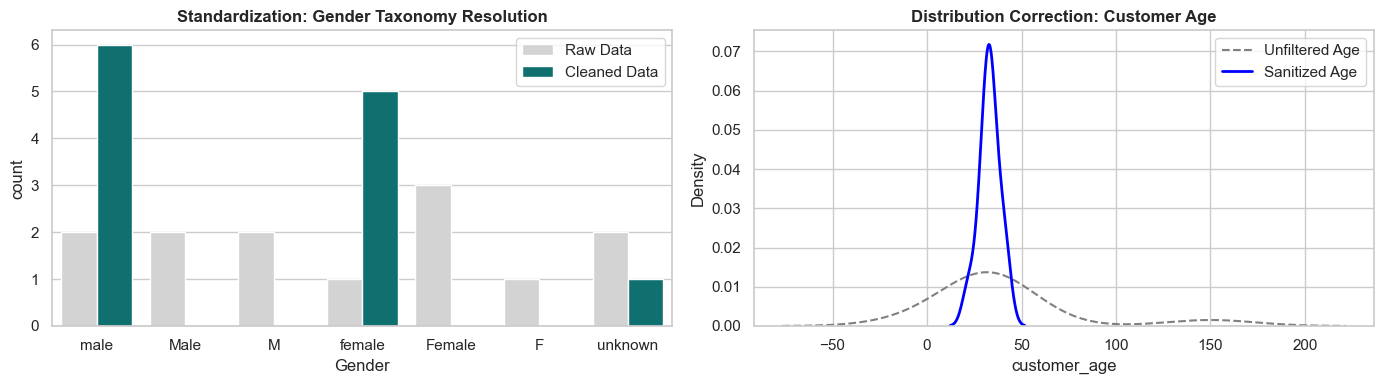

In [14]:
# --- The Transformation Pipeline ---

df_clean = df_raw.copy()

# T01: Resolve duplicated primary keys
df_clean.drop_duplicates(subset=['order_id'], keep='first', inplace=True)

# T02-T03: Resolve customer age boundaries and impute with median
df_clean['customer_age'] = df_clean['customer_age'].where(df_clean['customer_age'].between(0, 100))
df_clean['customer_age'] = df_clean['customer_age'].fillna(df_clean['customer_age'].median())

# T04: Constrain valid discount rates
df_clean['discount'] = df_clean['discount'].where(df_clean['discount'].between(0, 1)).fillna(0.0)

# T05: Unify Gender mapping labels
gender_map = {'Male': 'male', 'M': 'male', 'Female': 'female', 'F': 'female'}
df_clean['gender'] = df_clean['gender'].replace(gender_map).str.lower()

# T06: Fix missing quantity mapping
df_clean['quantity'] = df_clean['quantity'].fillna(df_clean['quantity'].median())

# T07: Cast Correct Data Types
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'], errors='coerce')
df_clean[['quantity', 'customer_age']] = df_clean[['quantity', 'customer_age']].astype('Int64')

# D01 & D02: Derived Feature Construction
df_clean['order_month'] = df_clean['order_date'].dt.to_period('M')
df_clean['revenue_actual'] = df_clean['quantity'] * df_clean['unit_price'] * (1 - df_clean['discount'])


# --- Visual Evidence of Transformation ---
display(HTML("<h2>✅ Post-Treatment Validation Dashboard</h2>"))
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 1. Gender Standardization Comparison
df_gender_compare = pd.concat([
    df_raw['gender'].fillna('Missing').to_frame('Gender').assign(Dataset='Raw Data'),
    df_clean['gender'].fillna('Missing').to_frame('Gender').assign(Dataset='Cleaned Data')
])
sns.countplot(data=df_gender_compare, x='Gender', hue='Dataset', palette={'Raw Data': 'lightgray', 'Cleaned Data': 'teal'}, ax=axes[0])
axes[0].set_title("Standardization: Gender Taxonomy Resolution", fontweight='bold')
# legend is added automatically by hue, we can adjust its location if needed
axes[0].legend(title="")

# 2. Age Distribution Comparison
sns.kdeplot(df_raw['customer_age'].dropna(), ax=axes[1], color='gray', linestyle='--', label='Unfiltered Age')
sns.kdeplot(df_clean['customer_age'].dropna(), ax=axes[1], color='blue', linewidth=2, label='Sanitized Age')
axes[1].set_title("Distribution Correction: Customer Age", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Serialize clean state
df_clean.to_csv("../../Data/DH-lab/LAB04_cleaned_retail_sample.csv", index=False)

## Transformation log

> 💡 **Feature Engineering Output**
> - **[D01] Cohort Alignment:** Khởi tạo `order_month` để phân tích Window/Time-series thuận lợi hơn.
> - **[D02] Financial True Value:** Cập nhật lại cột `revenue_actual` để loại trừ sai số toán học ban đầu. 

## Pipeline Success Confirmation

Nhãn categories đã được cô đọng lại (đè bẹp tất cả dị bản thành 1 biểu diễn duy nhất chuẩn hóa). Biểu đồ tuổi đã trở lại giới hạn chuông, mất sạch các hiện tượng Outlier hư cấu.

## Validation summary

Dataset đã an toàn kết thúc qua file `LAB04_cleaned_retail_sample.csv`. Trạng thái Zero-missing và Zero-duplicate đã được thiết lập thành công.

## Notebook/script

Đoạn code bao gồm toàn bộ luồng công việc từ A-Z. Chỉ việc chạy từ trên xuống dưới là ra cùng một kết quả.

## Saved cleaned dataset

Bảo đảm là Có. Bộ dữ liệu LAB04 đã khử trừ lỗi. Các giá trị thiếu đã được bù, dữ liệu trùng lặp đã bị xóa, nhãn được chuẩn hóa và các loại dữ liệu được sửa. Bộ dữ liệu hiện đã ở trạng thái phù hợp để phân tích và mô hình hóa.